
### Chains with LangGraph 
##### START --> Node 1 --> Node 2 --> Node n -->END. Sometimes the chain also between from Node 2 --> Node 1 also. I can be.
##### so far, we worked with Nodes, Normal Edges, Conditional Edges
### There FOUR components:
* 1. Chat Messages: These Chat Messages labeled who has given what message. Either HumanMessage or AIMessage, etc., etc. How to manage these chat messages within this workflow (START --> Node 1 --> Node 2 --> Node n -->END.) Also, our chat messages will be used in our Graph State to one node to the other node
* 2. Chat Models: When we create a complex flow using LLMs. Here, we talk about "How to use chat models in graph nodes?"
* 3. Binding Tools: Integrate with 3rd party APIs. Some external sources since they do not have up to date data. How do we bind tools to our chat model?
* 4. Execute tool calls from LLM in graph node

##### SUMMARY: How we can build a simple chain using LangGraph that uses 4 important concepts:
* How to use chat messages in our graph state?
* How to use chat models in graph nodes?
* How to bind tools to our LLM in chat models?
* How to execute the tools call in our graph nodes?


In [6]:
from dotenv import load_dotenv
load_dotenv() 

import os 
#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


### How to use chat messages as our graph state?
### Messages:
##### We can use messages which can be used to capture different roles within a conversation. LangChain has various messages types including HumanMessage,AIMessage,SystemMessage and ToolMessage. These represent a message from the user,from chat model, for that chat model to instruct behavior, and from a tool call.

##### Every message have these important components:
* content - content of the message
* name - Specify the name of the author 
* reponse_metadata - optionally, a dict of metadata (often populated as AIMessages)

In [8]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

# create a simple conversation like LLM do with a user
messages=[AIMessage(content=f"Please tell me how I can help?", name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Venkat"))
messages.append(AIMessage(content=f"Which programming language you want to learn?",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn Python",name="Venkat"))

for message in messages:
    message.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how I can help?
================================ Human Message =================================
Name: Venkat

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn?
================================ Human Message =================================
Name: Venkat

I want to learn Python


### Chat Models 
##### We can use the sequence of messages as input with the chatmodels using LLM's and OPEN AI


In [13]:
# passing the above messages to Groq LLM

from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")
llm.invoke(messages)

AIMessage(content='<think>\nAlright, the user wants to learn Python. Let me start by figuring out their current level. They didn\'t mention any prior experience, so I should assume they\'re a beginner. First, I need to outline a structured learning path. Maybe start with the basics like syntax, variables, and data types. Then move on to control structures, functions, and data structures like lists and dictionaries. After that, introduce more advanced topics such as object-oriented programming and modules.\n\nI should recommend some beginner-friendly resources. Books like "Python Crash Course" or "Automate the Boring Stuff" are good. Online platforms like Codecademy, Coursera, or freeCodeCamp might help. Also, interactive sites like Exercism or Codewars can be useful for practice. It\'s important to emphasize hands-on practice—maybe suggest small projects like a calculator or a to-do list app.\n\nWait, the user might not know where to start with projects. I should break down the learnin

In [14]:
result=llm.invoke(messages)
result.response_metadata

{'token_usage': {'completion_tokens': 1605,
  'prompt_tokens': 785,
  'total_tokens': 2390,
  'completion_time': 3.395466,
  'completion_tokens_details': None,
  'prompt_time': 0.037988,
  'prompt_tokens_details': None,
  'queue_time': 0.082108,
  'total_time': 3.433454},
 'model_name': 'groq/compound-mini',
 'system_fingerprint': None,
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None,
 'model_provider': 'groq'}

### Tools 
##### Tools can be integrated with LLM models to interact with external systems. Exteral systems can be APIs', third party tools.
##### Whenever a query is asked the model can choose to call the tool and this query is based on the natural language input and this will return an output that matches the tool's schema.

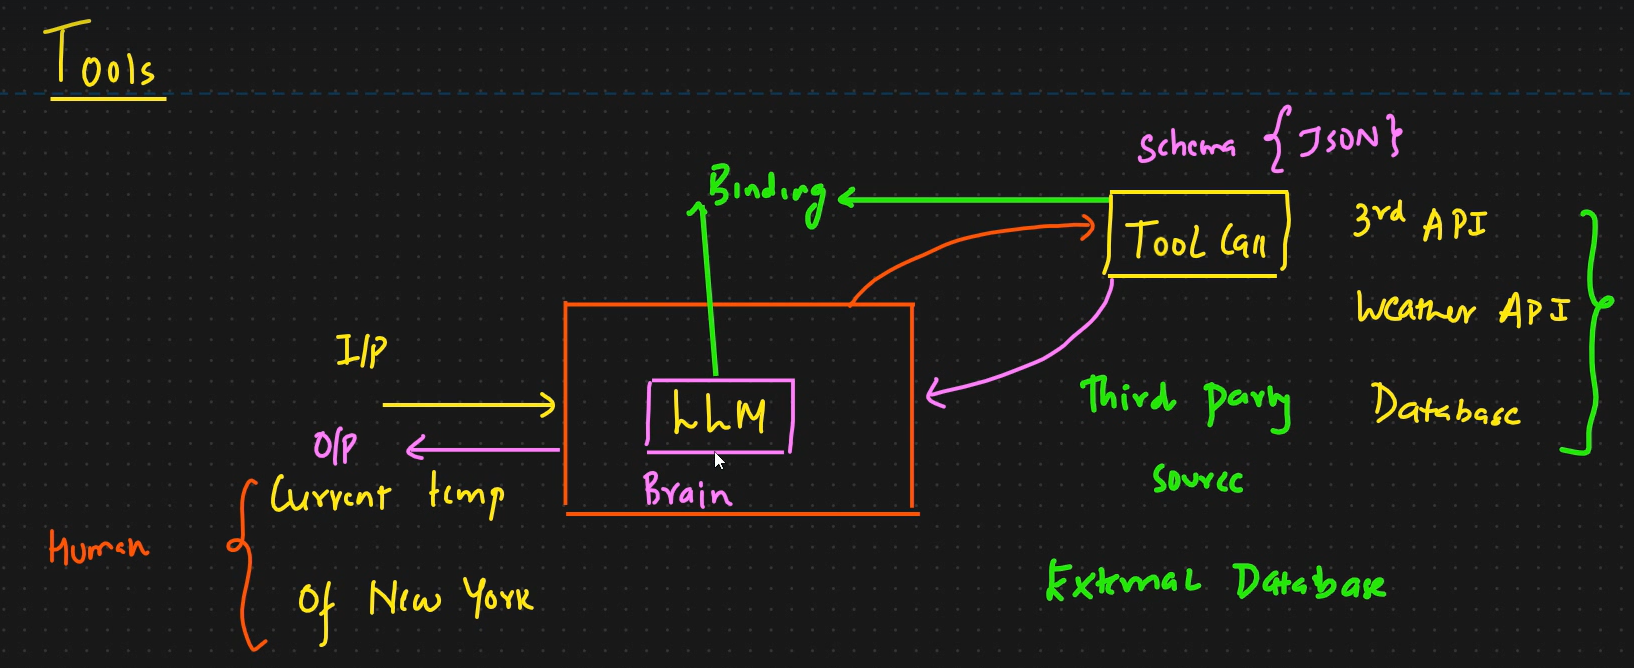
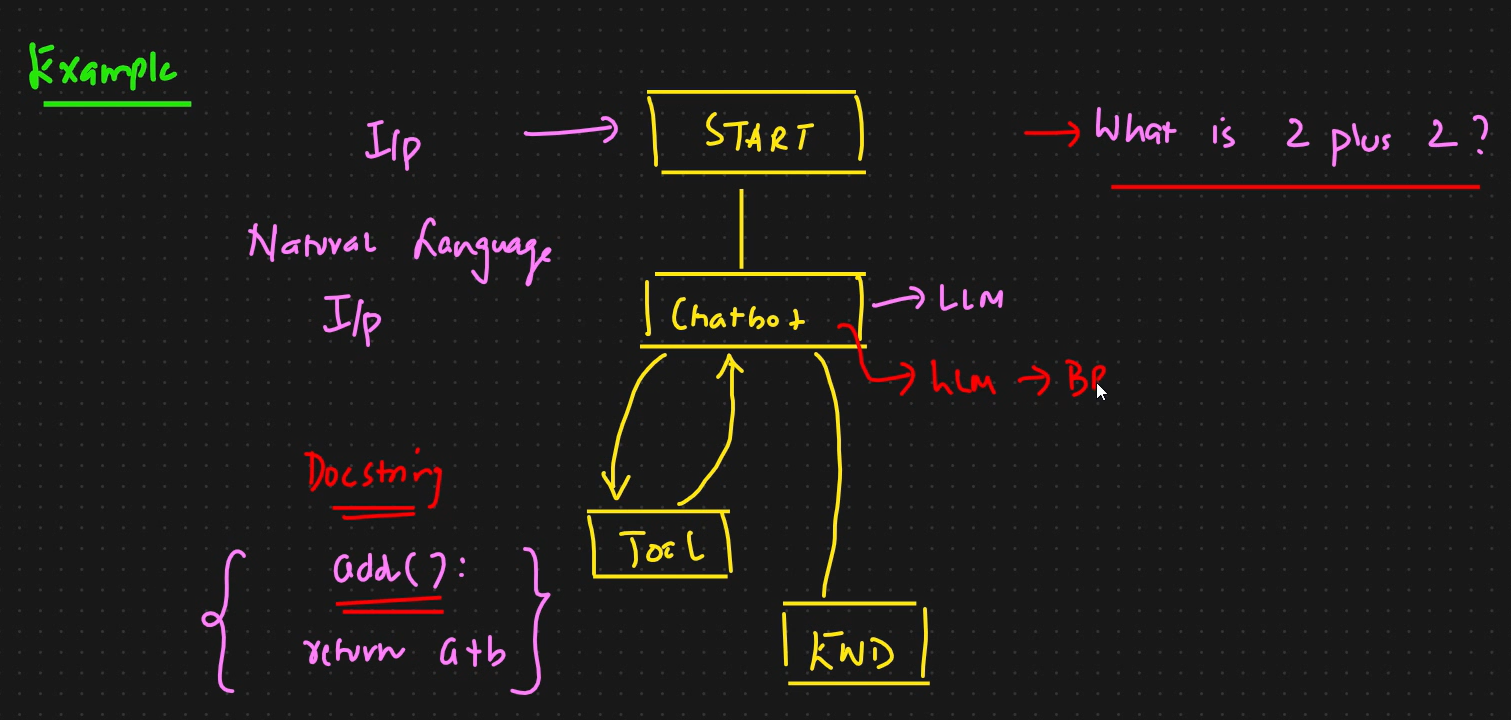


In [14]:
def add(a:int,b:int)->int:
 
 """
    Add a and b
Args:
    a (int): first int
    b(int) : second int
Returns:
    int
 """

 return a + b 

In [15]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BCF0C0F590>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BCF433D0D0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [16]:
### Binding tool with LLM 
llm_with_tools=llm.bind_tools([add])

In [17]:
llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2 ?",name="Venkat")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 2 plus 2?" I need to use the add function provided. The function requires two integers, a and b. Here, a is 2 and b is 2. So I\'ll call the add function with these values.\n', 'tool_calls': [{'id': 'x1bpw2da6', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 190, 'total_tokens': 276, 'completion_time': 0.13394201, 'completion_tokens_details': {'reasoning_tokens': 57}, 'prompt_time': 0.007443326, 'prompt_tokens_details': None, 'queue_time': 0.077940161, 'total_time': 0.141385336}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_efa9879028', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019b6c57-02d3-71f1-84dd-c0cd41bbedbc-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'x1bpw2da6', 'type

In [18]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2 ?",name="Venkat")])
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': '5y38x1y8m',
  'type': 'tool_call'}]

In [20]:
llm_with_tools.invoke([HumanMessage(content=f"What is 2 divide by 2 ?",name="Venkat")])

AIMessage(content='The result of 2 divided by 2 is 1. However, since the provided tools only include an addition function and no division function, I cannot use the available tool to compute this result. Let me know if you need further clarification!', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 2 divide by 2?" Let me see. The available tool is the add function, which adds two integers. But the user is asking about division. Since there\'s no division function provided, I can\'t use the tool to compute 2 divided by 2. I need to let them know that I can\'t perform division with the current tools. I should explain that the available function is for addition and perhaps suggest that they might need a different tool for division. Let me check if I can answer without the tool. 2 divided by 2 is 1, but since the tool isn\'t available, I should mention that I can\'t use the provided function for this. Hmm, but maybe the user just wants the answer directly. Even 

### Using messages as state

### Reducers



In [21]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]  #whenever there is message append, the current message override. That should not happen. for this use reducer.
    

Now, we have a minor problem. As we discussed, each node will return a new value for our state key messages. But, this new value will override the prior message value. As our graph runs, we want to append messages to our messages state key. We can use reducer functions to address this.
Reducers allow us to specify how state updates are performed. If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before. But, to append messages, we can use the pre-built add_messages reducer. This ensures that any messages are appended to the existing list of messages.We simply need to annotate our messages key with the add_messages reducer function as metadata

In [22]:
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    message:Annotated[list[AnyMessage],add_messages] # This add_messages reducer will append the messages to the list of messages


### How Reducers  work with add_messages?

In [26]:
initial_messages=[AIMessage(content=f"Please tellme how can I help you?",name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="Venkat"))

initial_messages

[AIMessage(content='Please tellme how can I help you?', additional_kwargs={}, response_metadata={}, name='LLMModel'),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Venkat')]

In [ ]:
ai_message=AIMessage(content=f"What programming language you want to learn?",name="LLMModel")
ai_message

AIMessage(content='What programming language you want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel')

In [30]:
### Reducers add_messages is to append instead of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tellme how can I help you?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='1842b41e-39b5-405f-9484-c2e333bf4887'),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Venkat', id='9d1d35f3-2764-4bee-b7d8-941ec0e23419'),
 AIMessage(content='You can try different languages for AI/ML', additional_kwargs={}, response_metadata={}, name='Venkat', id='630546bb-4f69-498c-9492-a61ea8e05fa6'),
 AIMessage(content='What programming language you want to learn?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='4b336336-fb36-43d2-b2e6-70b8073590e7')]

In [ ]:
initial_messages.append(AIMessage(content=f"You can try different languages for AI/ML",name="Venkat"))

initial_messages

[AIMessage(content='Please tellme how can I help you?', additional_kwargs={}, response_metadata={}, name='LLMModel', id='1842b41e-39b5-405f-9484-c2e333bf4887'),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Venkat', id='9d1d35f3-2764-4bee-b7d8-941ec0e23419'),
 AIMessage(content='You can try different languages for AI/ML', additional_kwargs={}, response_metadata={}, name='Venkat')]

In [38]:
### Chatbot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

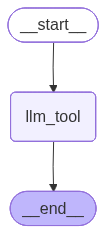

In [39]:

from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
builder = StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
###  Invocation 

from langchain_core.messages import HumanMessage

messages = graph.invoke({
    "messages": [HumanMessage(content="What is 2 plus 2")]
})

for message in messages["messages"]:
    message.pretty_print()


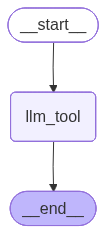

In [45]:
tools = [add]

from langgraph.prebuilt import ToolNode,tools_condition

builder=StateGraph(State)

# Add nodes 
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

# Add edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from messages is not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools",END)

graph_builder=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# This picture should add "tool" node since there is some issue with previous step, it didn't execute correctly.